# Feature Analysis

In [2]:
import sklearn
print(sklearn.__version__)

1.6.1


In [ ]:
"""Selection-level analysis of the Granger-causality features."""
import math
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch
import networkx as nx
from scipy import stats

DATA_DIR = Path(".")
OUT = Path("."); (OUT / "fig").mkdir(exist_ok=True, parents=True)
SEIZURE_ONLY = False   # include all 683 records
FIXED_K = 20                   # None = use tuned k_feat per record
PATIENT_NORMALISED = True
BANDS = ["delta", "theta", "alpha", "beta", "gamma"]
CH = list(range(1, 19))
BCOL = {"delta": "#3b4cc0", "theta": "#7b9ff9", "alpha": "#9aa0a6", "beta": "#f4a15c", "gamma": "#b40426"}
plt.rcParams.update({"font.size": 11, "font.family": "DejaVu Sans"})

# 1. Load and weight
def load():
    df = pd.read_csv(DATA_DIR / "LONG_SELECTED_FEATURES.csv")
    parts = df.feature_name.str.rsplit("_", n=2, expand=True)
    df["band"], df["src"], df["tgt"] = parts[0], parts[1].astype(int), parts[2].astype(int)
    ann = pd.read_csv(DATA_DIR / "seizure_annotations.csv")
    df["cls"] = np.where(df.record.isin(set(ann.file.unique())), "seizure", "nonseizure")
    if SEIZURE_ONLY:
        df = df[df.cls == "seizure"].copy()
    if FIXED_K:
        df = df[df["rank"] <= FIXED_K].copy()                # top-K per record
    kbase = FIXED_K if FIXED_K else df["k_feat"]
    df["w"] = kbase + 1 - df["rank"]                          # rank weight (rank 1 = highest)
    df["w"] = df["w"] / df.groupby(["patient", "record"])["w"].transform("sum")   # record sums to 1
    if PATIENT_NORMALISED:
        df["w"] = df["w"] / df.groupby("patient")["record"].transform("nunique")  # patient totals 1
    print("basis: %d records | FIXED_K=%s | PATIENT_NORMALISED=%s" % (df.record.nunique(), FIXED_K, PATIENT_NORMALISED))
    return df

def chan_profile(sub):
    o = sub.groupby("src")["w"].sum().reindex(CH, fill_value=0)
    i = sub.groupby("tgt")["w"].sum().reindex(CH, fill_value=0)
    return o, i

# 2. Frequency bands across the cohort (Figure 1, Table 1)
def cohort_bands(df):
    cnt = df["band"].value_counts().reindex(BANDS)               # counts (for chi-square)
    wsum = df.groupby("band")["w"].sum().reindex(BANDS)          # patient-normalised weight
    prop = wsum / wsum.sum() * 100                               # weighted band share
    distinct = df.drop_duplicates("feature_index").groupby("band").size().reindex(BANDS)
    meanw = df.groupby("band")["w"].mean().reindex(BANDS)
    chi2, p = stats.chisquare(cnt.values, np.full(5, cnt.sum() / 5))
    tbl = pd.DataFrame({"n": cnt, "share_%": prop.round(2),
                        "distinct_of_306": distinct, "coverage_%": (distinct / 306 * 100).round(1),
                        "overrep": (prop / 20).round(3), "mean_rank_w": (meanw * 1000).round(3)})
    print("\n[Table 1] cohort bands  chi2=%.0f p=%.1e  (%d selections over %d records)\n" % (chi2, p, len(df), df.record.nunique()), tbl)
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
    ax[0].bar(BANDS, prop, color=[BCOL[b] for b in BANDS], edgecolor="k", lw=.6)
    ax[0].axhline(20, ls="--", c="k"); ax[0].set_ylabel("% of selection weight"); ax[0].set_title("(a) Share per band")
    ax[1].bar(BANDS, prop / 20, color=[BCOL[b] for b in BANDS], edgecolor="k", lw=.6)
    ax[1].axhline(1, ls="--", c="k"); ax[1].set_title("(b) Over-/under-representation")
    ax[2].bar(BANDS, meanw * 1000, color=[BCOL[b] for b in BANDS], edgecolor="k", lw=.6, alpha=.85)
    ax[2].set_ylabel("mean rank-weight (x1e-3)"); ax[2].set_title("(c) Importance when selected")
    ax2 = ax[2].twinx(); ax2.plot(BANDS, distinct / 306 * 100, "ko-"); ax2.set_ylabel("distinct pairs used (%)")
    plt.tight_layout(); fig.savefig(OUT / "fig/fig1_bands.png", dpi=200, bbox_inches="tight"); plt.close()
    return tbl

# 3. Directionality across the cohort (Figure 2, Table 2)
def cohort_direction(df):
    o, i = chan_profile(df)
    deg = pd.DataFrame({"out": o.round(3), "in": i.round(3)})
    deg["net"] = (deg.out - deg["in"]).round(3); deg["total"] = (deg.out + deg["in"]).round(3)
    deg["asym"] = ((deg.out - deg["in"]) / (deg.out + deg["in"])).round(3)
    r = np.corrcoef(deg.out, deg["in"])[0, 1]
    print("\n[Table 2] cohort directionality  corr(out,in)=%.3f\n" % r, deg.sort_values("total", ascending=False))
    order = deg.sort_values("total", ascending=False).index; y = np.arange(18)
    fig, ax = plt.subplots(1, 2, figsize=(13, 6.2))
    ax[0].barh(y, o.reindex(order), color="#c0392b", label="outgoing", edgecolor="k", lw=.4)
    ax[0].barh(y, -i.reindex(order), color="#2471a3", label="incoming", edgecolor="k", lw=.4)
    ax[0].set_yticks(y); ax[0].set_yticklabels([f"ch{c}" for c in order]); ax[0].invert_yaxis()
    ax[0].axvline(0, c="k"); ax[0].legend(); ax[0].set_title("(a) Outgoing vs incoming weight")
    asym = deg.asym.reindex(order)
    ax[1].barh(y, asym, color=["#c0392b" if v > 0 else "#2471a3" for v in asym], edgecolor="k", lw=.4)
    ax[1].set_yticks(y); ax[1].set_yticklabels([f"ch{c}" for c in order]); ax[1].invert_yaxis()
    ax[1].axvline(0, c="k"); ax[1].set_xlim(-1, 1); ax[1].set_title("(b) Directional asymmetry")
    plt.tight_layout(); fig.savefig(OUT / "fig/fig2_direction.png", dpi=200, bbox_inches="tight"); plt.close()
    return deg, r

# 4. Network across the cohort (Figure 3, Table 3) and drawing helper
def draw_network(ax, edges, o, i, title, top_n=40, label_fs=11,):
    net = o - i
    G = nx.DiGraph(); [G.add_node(c) for c in CH]
    top = edges.sort_values("w", ascending=False).head(top_n)
    for r in top.itertuples(): G.add_edge(r.src, r.tgt)
    pos = {c: (math.cos(math.pi/2 - 2*math.pi*(c-1)/18), math.sin(math.pi/2 - 2*math.pi*(c-1)/18)) for c in CH}
    nsz = (o + i) / (o + i).max() * 2400 + 200
    norm = mcolors.TwoSlopeNorm(vmin=net.min()-1e-9, vcenter=0, vmax=net.max()+1e-9)
    nc = nx.draw_networkx_nodes(G, pos, node_size=[nsz[c] for c in CH], node_color=[net[c] for c in CH],
                                cmap="coolwarm", edgecolors="k", linewidths=1.1, ax=ax); nc.set_norm(norm)
    nx.draw_networkx_labels(G, pos, {c: str(c) for c in CH}, font_size=label_fs, font_weight="bold", ax=ax)
    wmax = top.w.max()
    for r in top.itertuples():
        ax.add_patch(FancyArrowPatch(pos[r.src], pos[r.tgt], connectionstyle="arc3,rad=0.12",
                     arrowstyle="-|>", mutation_scale=11, lw=0.4 + 3.2 * r.w / wmax,
                     color=plt.cm.Greys(0.35 + 0.6 * r.w / wmax), alpha=.8, zorder=0, shrinkA=13, shrinkB=14))
    ax.set_title(title); ax.axis("off")

def cohort_network(df, o, i):
    edges = df.groupby(["src", "tgt"])["w"].sum().reset_index()
    es = edges.sort_values("w", ascending=False).reset_index(drop=True)
    cum = es.w.cumsum() / es.w.sum()
    n50, n80 = int((cum < .5).sum()) + 1, int((cum < .8).sum()) + 1
    ew = {(r.src, r.tgt): r.w for r in es.itertuples()}
    recip = sum(min(w, ew.get((b, a), 0)) for (a, b), w in ew.items()) / sum(ew.values())
    print("\n[Table 3] top edges | edges=%d  50%%=%d  80%%=%d  reciprocity=%.3f" % (len(edges), n50, n80, recip))
    print(es.head(10).assign(w=es.w.round(4)).to_string(index=False))
    fig, ax = plt.subplots(figsize=(9, 9))
    draw_network(ax, edges, o, i, "Directed network of selected features (top 40 edges)")
    plt.tight_layout(); fig.savefig(OUT / "fig/fig3_network.png", dpi=200, bbox_inches="tight"); plt.close()
    return edges

# 5. Frequency by direction and separation gradient (Figure 4)
def cohort_freqdir(df):
    bsrc = df.pivot_table(index="src", columns="band", values="w", aggfunc="sum", fill_value=0).reindex(CH).reindex(columns=BANDS)
    btgt = df.pivot_table(index="tgt", columns="band", values="w", aggfunc="sum", fill_value=0).reindex(CH).reindex(columns=BANDS)
    d = df.assign(dist=(df.src - df.tgt).abs())
    spread = d.groupby("band").apply(lambda x: np.average(x.dist, weights=x.w), include_groups=False).reindex(BANDS)
    print("\n[Fig4] mean |src-tgt| separation per band\n", spread.round(2))
    fig, ax = plt.subplots(1, 3, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1, 1.05]})
    ax[0].imshow(bsrc.values, aspect="auto", cmap="Reds"); ax[0].set_title("(a) Source weight  ch x band")
    ax[1].imshow(btgt.values, aspect="auto", cmap="Blues"); ax[1].set_title("(b) Target weight  ch x band")
    for a in ax[:2]:
        a.set_xticks(range(5)); a.set_xticklabels(BANDS, rotation=30)
        a.set_yticks(range(18)); a.set_yticklabels([f"ch{c}" for c in CH])
    ax[2].plot(BANDS, spread, "o-", color="#6a0dad", lw=2, ms=8); ax[2].axhline(6, ls="--", c="gray")
    ax[2].set_title("(c) Structural separation by band"); ax[2].set_ylabel("weighted mean |src-tgt|")
    plt.tight_layout(); fig.savefig(OUT / "fig/fig4_interaction.png", dpi=200, bbox_inches="tight"); plt.close()

# 6. Per-patient metrics and consistency (Figures 5, 6, 7, 9; Table 5)
def per_patient(df):
    pats = sorted(df.patient.unique())
    pb = df.pivot_table(index="patient", columns="band", values="w", aggfunc="sum", fill_value=0).reindex(columns=BANDS)
    pbs = pb.div(pb.sum(1), axis=0)
    ent = -(pbs * np.log(pbs.replace(0, np.nan))).sum(1) / np.log(5)
    M = pbs.values
    cos = [np.dot(M[a], M[b]) / (np.linalg.norm(M[a]) * np.linalg.norm(M[b])) for a, b in combinations(range(len(pats)), 2)]
    print("\n[Table 5] gamma top in %d/%d ; mean band-profile cosine %.3f" % ((pbs.idxmax(1) == "gamma").sum(), len(pats), np.mean(cos)))
    print(pd.DataFrame({"mean": pbs.mean().round(3), "sd": pbs.std().round(3), "cv": (pbs.std() / pbs.mean()).round(2)}))
    order = pbs.gamma.sort_values().index
    fig, ax = plt.subplots(1, 2, figsize=(14, 7), gridspec_kw={"width_ratios": [1.5, 1]})
    im = ax[0].imshow(pbs.loc[order].values, aspect="auto", cmap="magma", vmin=0, vmax=.6)
    ax[0].set_xticks(range(5)); ax[0].set_xticklabels(BANDS); ax[0].set_yticks(range(len(pats))); ax[0].set_yticklabels(order, fontsize=9)
    ax[0].set_title("(a) Per-patient band share"); fig.colorbar(im, ax=ax[0], fraction=.046)
    bx = ax[1].boxplot([pbs[b] for b in BANDS], tick_labels=BANDS, patch_artist=True, showmeans=True)
    for patch, b in zip(bx["boxes"], BANDS): patch.set_facecolor(BCOL[b]); patch.set_alpha(.75)
    ax[1].axhline(.2, ls="--", c="k"); ax[1].set_title("(b) Between-patient variability")
    plt.tight_layout(); fig.savefig(OUT / "fig/fig5_patient_bands.png", dpi=200, bbox_inches="tight"); plt.close()

    rows, netmat = [], {}
    for p in pats:
        o, i = chan_profile(df[df.patient == p])
        asym = (o - i) / (o + i).replace(0, np.nan)
        src2 = o.sort_values(ascending=False).index[:2].tolist()
        e = df[df.patient == p].groupby(["src", "tgt"])["w"].sum().sort_values(ascending=False)
        sep = np.average((df[df.patient == p].src - df[df.patient == p].tgt).abs(), weights=df[df.patient == p].w)
        x = np.sort(e.values); n = len(x); gini = (2 * np.arange(1, n+1) - n - 1).dot(x) / (n * x.sum())
        rows.append(dict(patient=p, top_src=int(o.idxmax()), top_src_asym=round(asym.get(int(o.idxmax()), np.nan), 3),
                         top_sink=int(i.idxmax()), top2_src_share=round(o.loc[src2].sum() / o.sum(), 3),
                         ch17_18_in_top2src=int(bool(set(src2) & {17, 18})),
                         edges_used=int(e.shape[0]), top10_share=round(e.head(10).sum() / e.sum(), 3),
                         gini=round(gini, 3), mean_sep=round(sep, 2)))
        netmat[p] = (o - i).values
    pp = pbs.round(4).reset_index().merge(pd.DataFrame(rows), on="patient")
    pp["low_share"] = pbs[["delta", "theta"]].sum(1).values.round(4); pp["entropy"] = ent.values.round(3)
    c1718 = sum(set(chan_profile(df[df.patient == p])[0].sort_values(ascending=False).index[:2]) == {17, 18} for p in pats)
    print("  {17,18} top-2 sources in %d/%d ; ch5 top sink in %d/%d" % (c1718, len(pats), sum(int(chan_profile(df[df.patient == p])[1].idxmax()) == 5 for p in pats), len(pats)))
    print("  top10 share %.2f-%.2f ; edges %d-%d ; sep %.1f-%.1f" % (pp.top10_share.min(), pp.top10_share.max(), pp.edges_used.min(), pp.edges_used.max(), pp.mean_sep.min(), pp.mean_sep.max()))

    nf = np.zeros((18, len(pats)))
    for j, p in enumerate(pats):
        net = netmat[p]; nf[:, j] = net / np.abs(net).max()
    fig, ax = plt.subplots(figsize=(13, 6))
    im = ax.imshow(nf, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_yticks(range(18)); ax.set_yticklabels([f"ch{c}" for c in CH], fontsize=9)
    ax.set_xticks(range(len(pats))); ax.set_xticklabels(pats, rotation=90, fontsize=9)
    ax.set_title("Per-patient net flow by channel (red=source, blue=sink; per-patient normalised)")
    fig.colorbar(im, ax=ax, fraction=.025, pad=.01)
    plt.tight_layout(); fig.savefig(OUT / "fig/fig6_patient_netflow.png", dpi=200, bbox_inches="tight"); plt.close()

    NM = np.array([netmat[p] for p in pats])
    feat = np.hstack([pbs.loc[pats].values, NM / np.linalg.norm(NM, axis=1, keepdims=True)])
    dist = np.linalg.norm(feat - feat.mean(0), axis=1)
    typical, outlier = pats[int(dist.argmin())], pats[int(dist.argmax())]
    print("  typical=%s  outlier=%s" % (typical, outlier))

    fig, ax = plt.subplots(figsize=(9, 6.5))
    sc = ax.scatter(pp.mean_sep, pp.top10_share, s=(pp.edges_used - pp.edges_used.min() + 10) * 6, c=pp.gamma, cmap="viridis", edgecolors="k", lw=.6)
    for _, r in pp.iterrows(): ax.annotate(r.patient.replace("chb", ""), (r.mean_sep, r.top10_share), fontsize=7, ha="center", va="center")
    ax.set_xlabel("mean |src-tgt| separation (local <-> long-range)")
    ax.set_ylabel("top-10 edge share (distributed <-> focal)"); fig.colorbar(sc, ax=ax, label="gamma share")
    plt.tight_layout(); fig.savefig(OUT / "fig/fig7_patient_network.png", dpi=200, bbox_inches="tight"); plt.close()

    fig, ax = plt.subplots(1, 2, figsize=(15, 7.6))
    for a, p, tag in [(ax[0], typical, "typical"), (ax[1], outlier, "outlier")]:
        sub = df[df.patient == p]; o, i = chan_profile(sub)
        draw_network(a, sub.groupby(["src", "tgt"])["w"].sum().reset_index(), o, i, f'"{tag}" patient {p}', top_n=25, label_fs=9)
    plt.tight_layout(); fig.savefig(OUT / "fig/fig9_example_nets.png", dpi=200, bbox_inches="tight"); plt.close()
    return pp

# 7. (not used)
def class_conditional(df):
    raise RuntimeError("Invalid on the selection log: non-seizure selections are inherited. Use gc_ictal_analysis.py.")

# 8. Merge with performance and correlations (Figure 10, Table 7)
def performance(pp):
    ev = pd.read_csv(DATA_DIR / "EVENTS_MAIN_MODEL.csv")
    seg = pd.read_csv(DATA_DIR / "SEGMENTS_MAIN_MODEL.csv")
    evp = ev.groupby("patient").agg(n_events=("detected", "size"), event_sens=("detected", "mean"),
          med_latency=("latency_s", lambda s: s[ev.loc[s.index, "detected"] == 1].median())).reset_index()
    seg["fa_per_hour"] = seg.fp / (seg.record_length / 3600.0)
    segp = seg.groupby("patient").agg(roc_auc=("roc_auc", "mean"), seg_sens=("seg_sensitivity", "mean"),
           seg_spec=("seg_specificity", "mean"), fp_total=("fp", "sum"), fa_per_hour=("fa_per_hour", "mean")).reset_index()
    M = pp.merge(evp, on="patient").merge(segp, on="patient")
    M.to_csv(OUT / "per_patient_full.csv", index=False)
    descr = ["gamma", "low_share", "top10_share", "top2_src_share", "mean_sep", "edges_used"]
    perfm = ["event_sens", "roc_auc", "seg_sens", "fa_per_hour"]
    print("\n[Table 7] Spearman(descriptor, performance) n=%d" % len(M))
    for dvar in descr:
        cells = []
        for pm in perfm:
            r, pv = stats.spearmanr(M[dvar], M[pm]); cells.append("%s=%+.2f%s" % (pm[:8], r, "*" if pv < .05 else ""))
        print("  %-15s %s" % (dvar, "  ".join(cells)))
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
    def sc(a, xc, yc, xl, yl, t):
        a.scatter(M[xc], M[yc], s=55, c="#2E5496", edgecolors="k", lw=.5)
        for _, r in M.iterrows(): a.annotate(r.patient.replace("chb", ""), (r[xc], r[yc]), fontsize=7)
        rr, pv = stats.spearmanr(M[xc], M[yc]); b, c = np.polyfit(M[xc], M[yc], 1)
        xs = np.linspace(M[xc].min(), M[xc].max(), 10); a.plot(xs, b * xs + c, "r--")
        a.set_xlabel(xl); a.set_ylabel(yl); a.set_title("%s\nSpearman r=%+.2f, p=%.3f" % (t, rr, pv))
    sc(ax[0], "top2_src_share", "seg_sens", "top-2 source concentration", "segment sensitivity", "(a) Hub conc. vs sens.")
    sc(ax[1], "edges_used", "fa_per_hour", "distinct edges used", "false alarms / hour", "(b) Spread vs false alarms")
    plt.tight_layout(); fig.savefig(OUT / "fig/fig10_performance.png", dpi=200, bbox_inches="tight"); plt.close()
    return M

if __name__ == "__main__":
    df = load(); df.to_parquet(OUT / "proc.parquet")
    cohort_bands(df)
    cohort_direction(df)
    o, i = chan_profile(df)
    cohort_network(df, o, i)
    cohort_freqdir(df)
    pp = per_patient(df)
    performance(pp)
    print("\nDONE -> fig/fig1..fig7,fig9,fig10, per_patient_full.csv, proc.parquet")

SyntaxError: parameter without a default follows parameter with a default (4152114270.py, line 127)

## Plot

Records analysed: 138
Patients analysed: 24
Selections analysed: 2760

Band selection table
       n_selected  weighted_share_%  overrepresentation
band                                                   
delta         461             19.89               0.995
theta         394             14.30               0.715
alpha         524             20.58               1.029
beta          465             16.31               0.816
gamma         916             28.92               1.446

Chi-square = 315.388, p = 5.188e-67


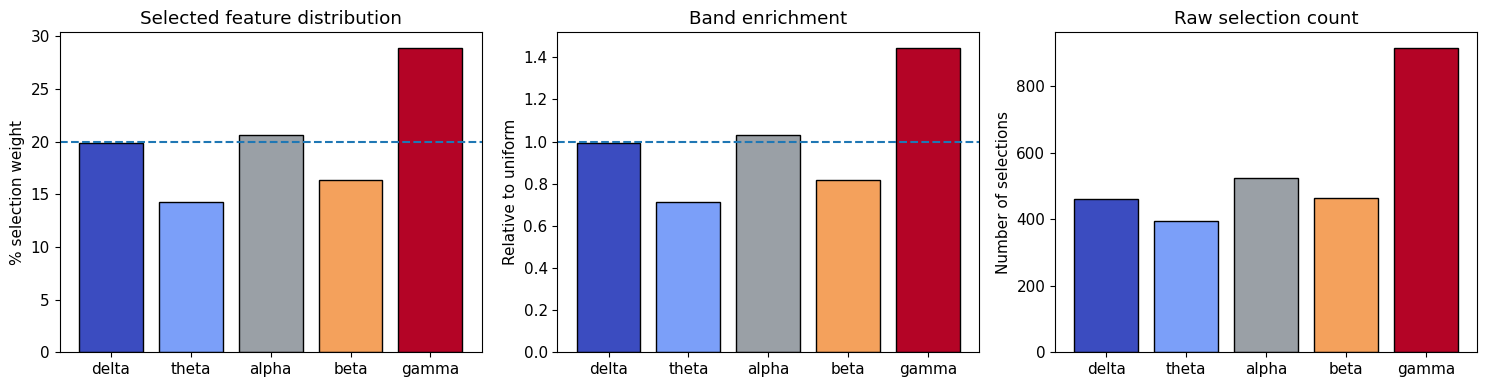

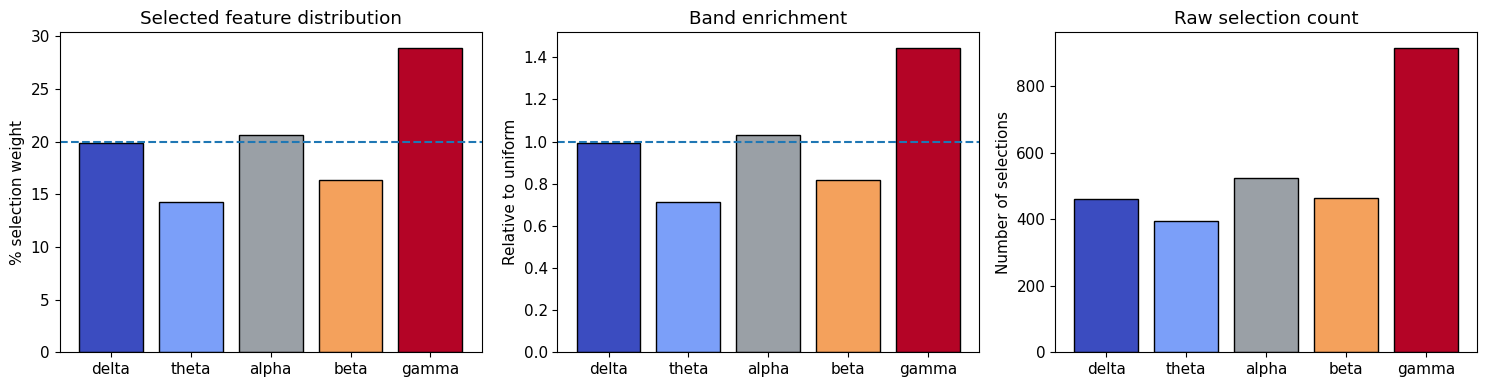

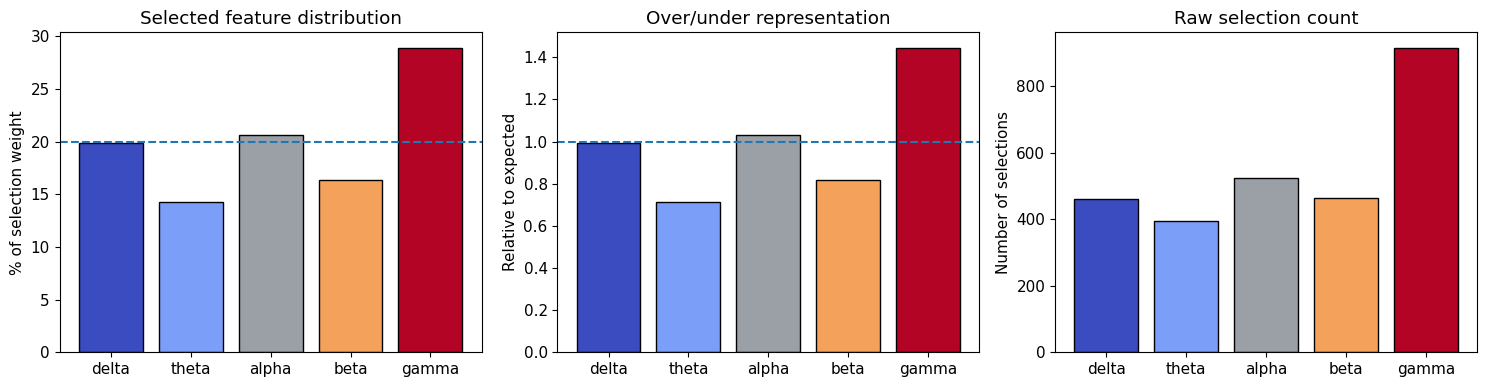

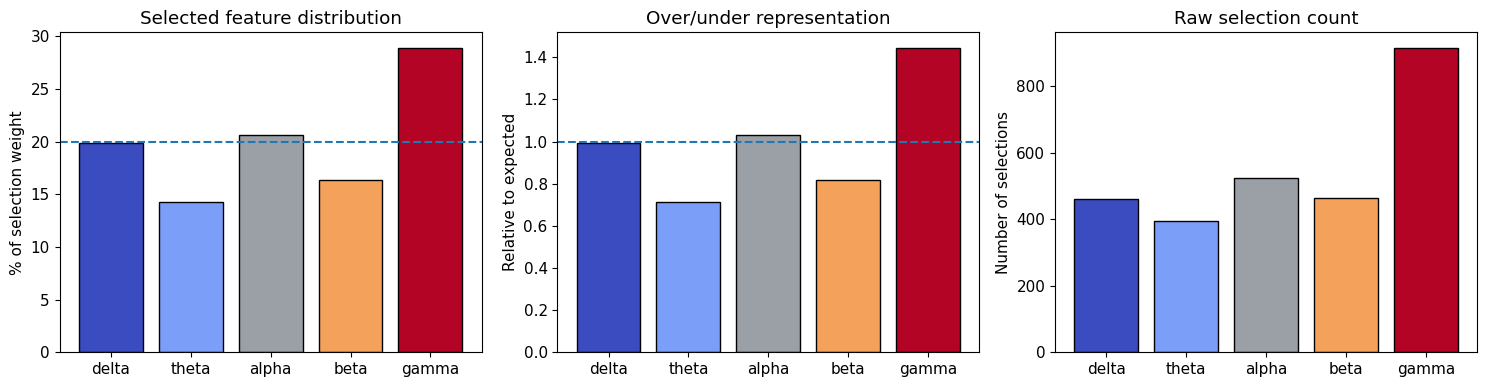

In [18]:
"""Selection-level analysis of the Granger-causality features (plots only)."""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


# Settings

DATA_DIR = Path(".")

SEIZURE_ONLY = True
FIXED_K = 20
PATIENT_NORMALISED = True

BANDS = ["delta", "theta", "alpha", "beta", "gamma"]

BCOL = {
    "delta": "#3b4cc0",
    "theta": "#7b9ff9",
    "alpha": "#9aa0a6",
    "beta": "#f4a15c",
    "gamma": "#b40426"
}


# Load data

def load():

    df = pd.read_csv(DATA_DIR / "LONG_SELECTED_FEATURES.csv")

    # Expected:
    # band_source_target
    parts = df.feature_name.str.rsplit("_", n=2, expand=True)

    df["band"] = parts[0]
    df["src"] = parts[1].astype(int)
    df["tgt"] = parts[2].astype(int)

    ann = pd.read_csv(DATA_DIR / "seizure_annotations.csv")

    seizure_files = set(ann.file.unique())

    df["class"] = np.where(
        df.record.isin(seizure_files),
        "seizure",
        "nonseizure"
    )


    if SEIZURE_ONLY:
        df = df[df["class"] == "seizure"].copy()


    # Equal feature budget per record
    if FIXED_K:
        df = df[df["rank"] <= FIXED_K].copy()


    # Rank weighting
    k = FIXED_K if FIXED_K else df["k_feat"]

    df["weight"] = k + 1 - df["rank"]


    # Each record contributes equally
    df["weight"] = (
        df["weight"]
        /
        df.groupby(["patient", "record"])["weight"]
        .transform("sum")
    )


    # Each patient contributes equally
    if PATIENT_NORMALISED:

        n_records = (
            df.groupby("patient")["record"]
            .transform("nunique")
        )

        df["weight"] = df["weight"] / n_records


    print(
        f"Records analysed: {df.record.nunique()}"
    )

    print(
        f"Patients analysed: {df.patient.nunique()}"
    )

    print(
        f"Selections analysed: {len(df)}"
    )


    return df


# Band analysis

def cohort_bands(df):

    # Raw number of selections
    counts = (
        df["band"]
        .value_counts()
        .reindex(BANDS)
        .fillna(0)
    )


    # Weighted importance
    weighted = (
        df.groupby("band")["weight"]
        .sum()
        .reindex(BANDS)
    )


    percentage = (
        weighted /
        weighted.sum()
        * 100
    )


    # Chi-square test
    chi2, p = stats.chisquare(
        counts.values,
        np.ones(5) * counts.sum() / 5
    )


    table = pd.DataFrame({

        "n_selected": counts.astype(int),

        "weighted_share_%":
            percentage.round(2),

        "overrepresentation":
            (percentage / 20).round(3)

    })


    print("\nBand selection table")
    print(table)

    print(
        f"\nChi-square = {chi2:.3f}, p = {p:.3e}"
    )


    # Plots

    fig, ax = plt.subplots(
        1,
        3,
        figsize=(15, 4)
    )


    # 1. Percentage contribution

    ax[0].bar(
        BANDS,
        percentage,
        color=[BCOL[b] for b in BANDS],
        edgecolor="black"
    )

    ax[0].axhline(
        20,
        linestyle="--"
    )

    ax[0].set_ylabel(
        "% of selection weight"
    )

    ax[0].set_title(
        "Selected feature distribution"
    )


    # 2. Relative enrichment

    ax[1].bar(
        BANDS,
        percentage / 20,
        color=[BCOL[b] for b in BANDS],
        edgecolor="black"
    )

    ax[1].axhline(
        1,
        linestyle="--"
    )

    ax[1].set_ylabel(
        "Relative to expected"
    )

    ax[1].set_title(
        "Over/under representation"
    )


    # 3. Raw counts

    ax[2].bar(
        BANDS,
        counts,
        color=[BCOL[b] for b in BANDS],
        edgecolor="black"
    )

    ax[2].set_ylabel(
        "Number of selections"
    )

    ax[2].set_title(
        "Raw selection count"
    )


    plt.tight_layout()

    plt.show()


# Run the conversion

df = load()

cohort_bands(df)

## Analysis

In [23]:
df = pd.read_csv(DATA_DIR / "LONG_SELECTED_FEATURES.csv")

In [24]:
top20 = df[df["rank"] <= 20].copy()

In [109]:
# Extract band, source, target
parts = top20.feature_name.str.rsplit("_", n=2, expand=True)

top20["band"] = parts[0]
top20["src"] = parts[1].astype(int)
top20["tgt"] = parts[2].astype(int)

In [27]:
top20["rank_weight"] = 21 - top20["rank"]

In [ ]:
top20["rank_weight"] = (
    top20["rank_weight"] /
    top20.groupby("record")["rank_weight"].transform("sum")
)

In [29]:
top20.groupby("record")["rank_weight"].sum()

record
chb01_01    1.0
chb01_02    1.0
chb01_03    1.0
chb01_04    1.0
chb01_05    1.0
           ... 
chb24_18    1.0
chb24_19    1.0
chb24_20    1.0
chb24_21    1.0
chb24_22    1.0
Name: rank_weight, Length: 683, dtype: float64

In [30]:
n_records_patient = (
    top20.groupby("patient")["record"]
    .transform("nunique")
)

top20["rank_weight_patient"] = (
    top20["rank_weight"] / n_records_patient
)

In [31]:
band_summary = (
    top20.groupby("band")["rank_weight_patient"]
    .sum()
)

band_summary = (
    band_summary /
    band_summary.sum()
    * 100
)

print(band_summary)

band
alpha    20.650991
beta     15.946370
delta    19.439991
gamma    29.494420
theta    14.468228
Name: rank_weight_patient, dtype: float64


## Which features are selected most often?

In [33]:
feature_frequency = (
    top20["feature_name"]
    .value_counts()
    .reset_index()
)

feature_frequency.columns = [
    "feature",
    "count"
]

print(feature_frequency.head(20))

        feature  count
0    alpha_18_5    250
1   gamma_17_18    198
2   gamma_18_11    183
3    delta_18_5    161
4    alpha_18_9    155
5     beta_18_5    153
6    gamma_18_8    153
7    theta_18_5    149
8    delta_17_6    137
9    delta_18_6    135
10  alpha_17_10    135
11   delta_17_3    134
12   delta_18_7    125
13  theta_18_11    122
14  delta_18_11    118
15   delta_17_2    116
16   beta_18_11    112
17   gamma_18_7    110
18  theta_17_10    106
19   delta_18_9    106


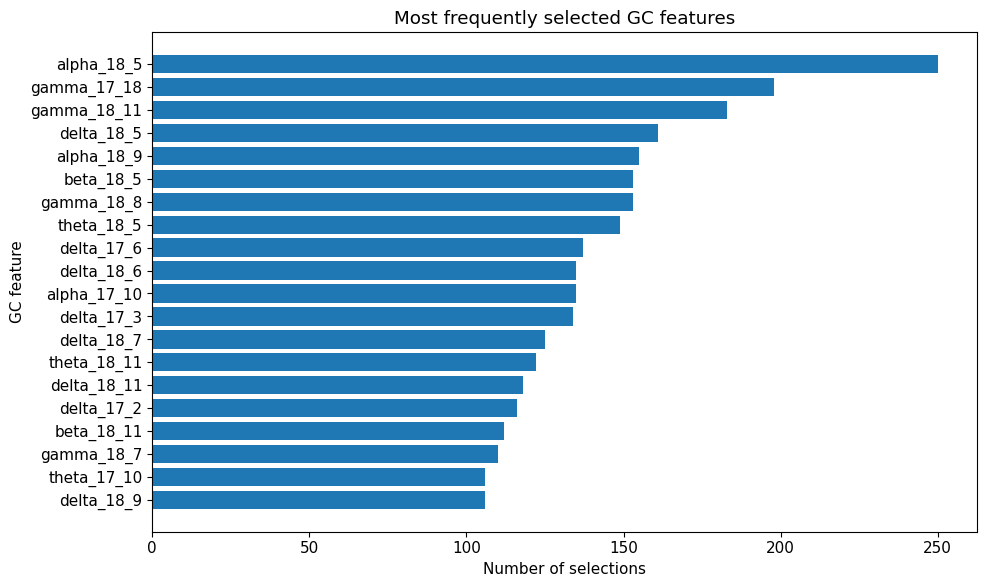

In [34]:
import matplotlib.pyplot as plt

top = feature_frequency.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top["feature"][::-1],
    top["count"][::-1]
)

plt.xlabel("Number of selections")
plt.ylabel("GC feature")
plt.title("Most frequently selected GC features")

plt.tight_layout()
plt.show()

## Which frequency bands are selected most?

In [35]:
parts = top20.feature_name.str.split("_", expand=True)

top20["band"] = parts[0]

In [36]:
band_counts = (
    top20["band"]
    .value_counts()
)

print(band_counts)

band
gamma    4134
alpha    2706
delta    2550
beta     2298
theta    1972
Name: count, dtype: int64


In [37]:
band_weight = (
    top20.groupby("band")["rank_weight"]
    .sum()
)

band_weight = (
    band_weight /
    band_weight.sum()
    *100
)

print(band_weight)

band
alpha    21.236143
beta     15.335704
delta    19.474308
gamma    29.590741
theta    14.363104
Name: rank_weight, dtype: float64


In [112]:
# Rank weighting
top20["rank_weight"] = 21 - top20["rank"]

# Sum rank-weighted contribution per patient and band
patient_band = (
    top20
    .groupby(["patient", "band"])["rank_weight"]
    .sum()
    .reset_index()
)

# Total contribution per patient
patient_total = (
    patient_band
    .groupby("patient")["rank_weight"]
    .transform("sum")
)

# Convert each patient's bands into percentages
patient_band["band_share"] = (
    patient_band["rank_weight"] /
    patient_total * 100
)

# Average across patients (each patient contributes equally)
band_share = (
    patient_band
    .groupby("band")["band_share"]
    .mean()
)

print(band_share)

band
alpha    20.650991
beta     15.946370
delta    20.285208
gamma    29.494420
theta    14.468228
Name: band_share, dtype: float64


band
alpha    20.650991
beta     15.946370
delta    20.285208
gamma    29.494420
theta    14.468228
Name: band_share, dtype: float64


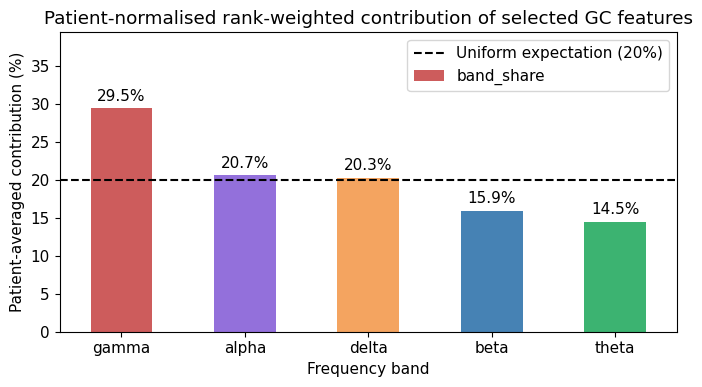

In [113]:
import matplotlib.pyplot as plt

# Patient-normalised rank-weighted band contribution

# Higher-ranked features receive higher weight
top20["rank_weight"] = 21 - top20["rank"]

# Sum contribution of each band within each patient
patient_band = (
    top20
    .groupby(["patient", "band"])["rank_weight"]
    .sum()
    .reset_index()
)

# Total selected feature contribution per patient
patient_total = (
    patient_band
    .groupby("patient")["rank_weight"]
    .transform("sum")
)

# Convert each patient's band contribution to percentage
patient_band["band_share"] = (
    patient_band["rank_weight"] /
    patient_total * 100
)

# Average across patients (equal contribution from all patients)
band_share = (
    patient_band
    .groupby("band")["band_share"]
    .mean()
)


print(band_share)


# Plot

# Uniform baseline
baseline = 20  # 5 bands -> 100/5

# Consistent colours by band
band_colors = {
    "delta": "sandybrown",
    "theta": "mediumseagreen",
    "alpha": "mediumpurple",
    "beta": "steelblue",
    "gamma": "indianred"
}

# Sort for plotting
band_share_sorted = band_share.sort_values(ascending=False)

colors = [
    band_colors[b]
    for b in band_share_sorted.index
]


plt.figure(figsize=(7,4))

band_share_sorted.plot(
    kind="bar",
    color=colors
)

# Expected equal contribution
plt.axhline(
    baseline,
    linestyle="--",
    color="black",
    label="Uniform expectation (20%)"
)

plt.ylabel("Patient-averaged contribution (%)")
plt.xlabel("Frequency band")
plt.title(
    "Patient-normalised rank-weighted contribution of selected GC features"
)

plt.xticks(rotation=0)
plt.legend()


# Add percentages
for i, v in enumerate(band_share_sorted):
    plt.text(
        i,
        v + 1,
        f"{v:.1f}%",
        ha="center"
    )

plt.ylim(
    0,
    max(band_share_sorted) + 10
)

plt.tight_layout()
plt.show()

## Which bands are ranked higher?

In [38]:
band_rank = (
    top20
    .groupby("band")["rank"]
    .agg(
        [
            "count",
            "mean",
            "median"
        ]
    )
)

print(band_rank)

       count       mean  median
band                           
alpha   2706   9.743902     9.0
beta    2298  11.428198    12.0
delta   2550  10.046275    10.0
gamma   4134  10.733430    11.0
theta   1972  10.553245    10.0


C:\Users\ritaw\AppData\Local\Temp\ipykernel_6476\2211799851.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


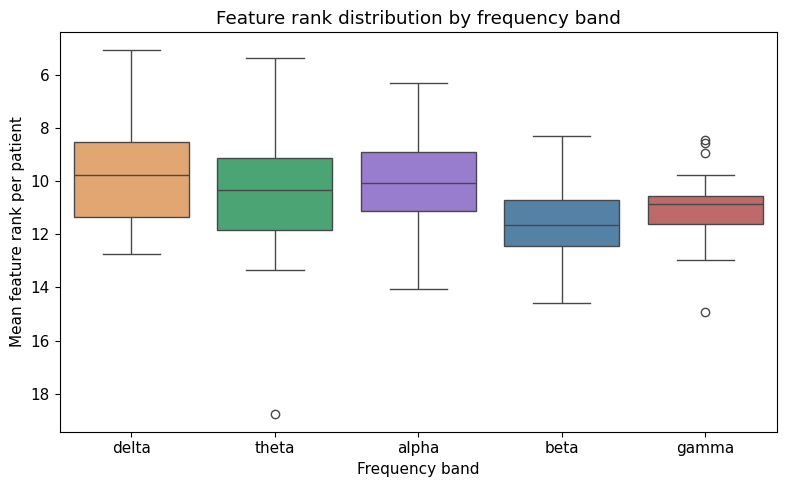

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

# Patient-normalised rank distribution
# same colours
band_colors = {
    "delta": "sandybrown",
    "theta": "mediumseagreen",
    "alpha": "mediumpurple",
    "beta": "steelblue",
    "gamma": "indianred"
}

# desired order
order = ["gamma", "alpha", "delta", "beta", "theta"]

# Average rank per patient and band
patient_band_rank = (
    top20
    .groupby(["patient", "band"])["rank"]
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(8,5))

sns.boxplot(
    data=patient_band_rank,
    x="band",
    y="rank",
    order=["delta", "theta", "alpha", "beta", "gamma"],
       palette=band_colors
)

plt.gca().invert_yaxis()

plt.xlabel("Frequency band")
plt.ylabel("Mean feature rank per patient")
plt.title(
    "Feature rank distribution by frequency band"
)

plt.tight_layout()
plt.show()

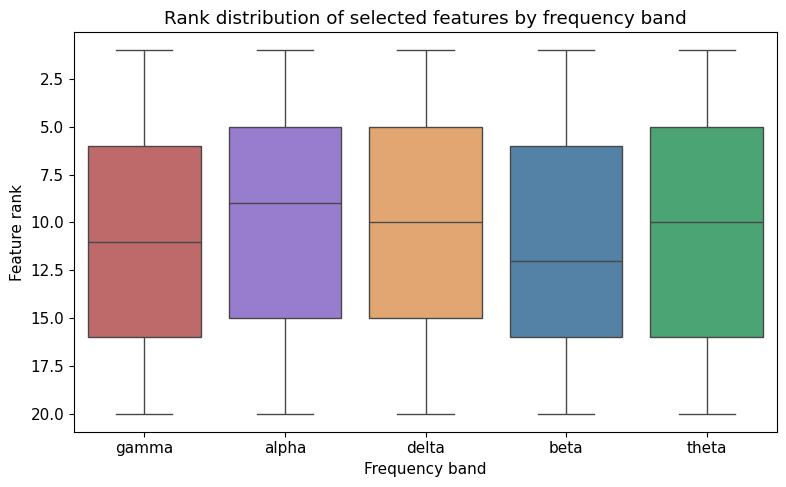

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

# same colours
band_colors = {
    "delta": "sandybrown",
    "theta": "mediumseagreen",
    "alpha": "mediumpurple",
    "beta": "steelblue",
    "gamma": "indianred"
}

# desired order
order = ["gamma", "alpha", "delta", "beta", "theta"]

plt.figure(figsize=(8,5))

sns.boxplot(
    data=top20,
    x="band",
    y="rank",
    order=order,
    hue="band",
    palette=band_colors,
    legend=False
)

plt.gca().invert_yaxis()

plt.xlabel("Frequency band")
plt.ylabel("Feature rank")
plt.title("Rank distribution of selected features by frequency band")

plt.tight_layout()
plt.show()

## Which channels are involved?

In [40]:
parts = top20.feature_name.str.split("_", expand=True)

top20["band"] = parts[0]
top20["source"] = parts[1].astype(int)
top20["target"] = parts[2].astype(int)

In [41]:
incoming = (
    top20["target"]
    .value_counts()
)

print(incoming)

target
5     1366
9     1051
11     971
6      962
12     937
7      927
10     869
13     812
3      734
8      708
15     675
2      672
18     660
17     574
14     543
16     469
1      381
4      349
Name: count, dtype: int64


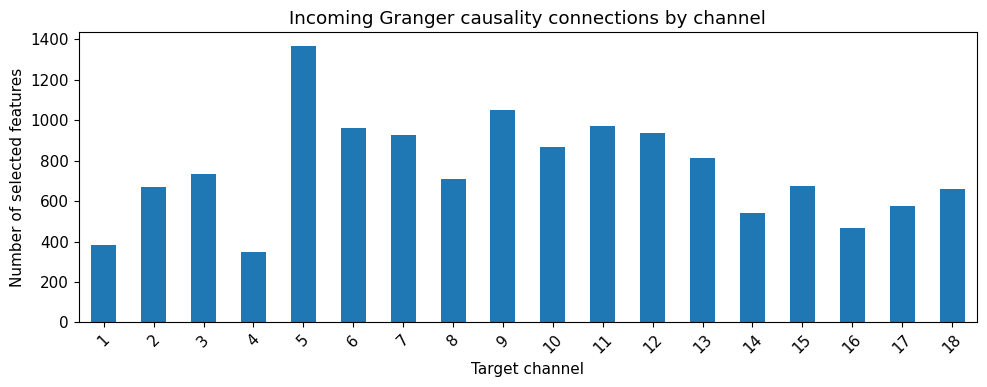

In [50]:
import matplotlib.pyplot as plt

incoming = (
    top20["target"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,4))

incoming.plot(
    kind="bar"
)

plt.xlabel("Target channel")
plt.ylabel("Number of selected features")
plt.title("Incoming Granger causality connections by channel")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [42]:
outgoing = (
    top20["source"]
    .value_counts()
)

print(outgoing)

source
18    4640
17    3878
11     598
8      484
7      473
12     465
4      406
5      362
16     351
6      342
1      308
10     269
3      223
9      195
13     175
15     173
2      164
14     154
Name: count, dtype: int64


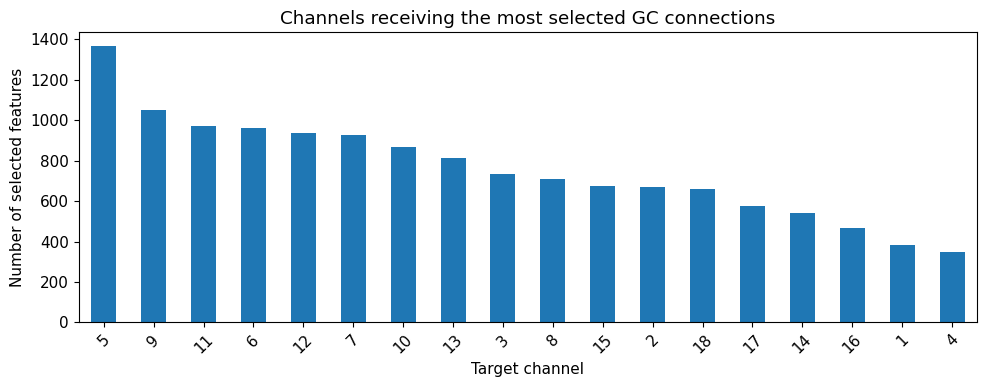

In [51]:
incoming = (
    top20["target"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,4))

incoming.plot(
    kind="bar"
)

plt.xlabel("Target channel")
plt.ylabel("Number of selected features")
plt.title("Channels receiving the most selected GC connections")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

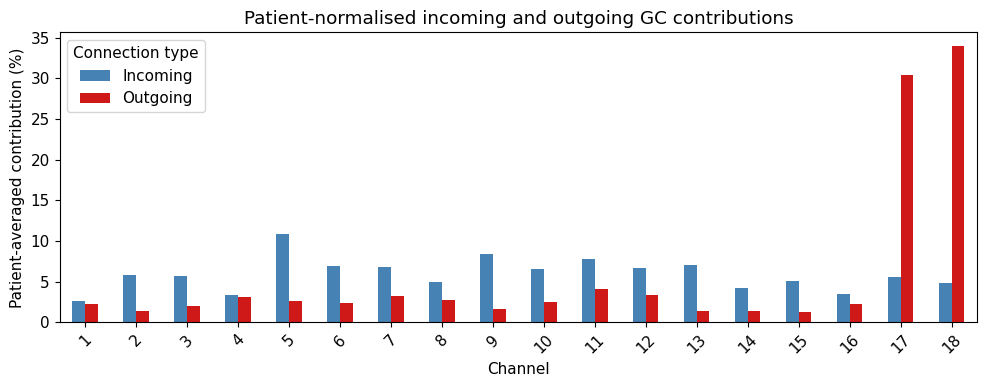

In [138]:
import matplotlib.pyplot as plt
import pandas as pd

# Rank weighting
top20["rank_weight"] = 21 - top20["rank"]

# Source (outgoing) contribution

source_patient = (
    top20
    .groupby(["patient", "source"])["rank_weight"]
    .sum()
    .reset_index()
)

source_total = (
    source_patient
    .groupby("patient")["rank_weight"]
    .transform("sum")
)

source_patient["contribution"] = (
    source_patient["rank_weight"] /
    source_total * 100
)


# Target (incoming) contribution

target_patient = (
    top20
    .groupby(["patient", "target"])["rank_weight"]
    .sum()
    .reset_index()
)

target_total = (
    target_patient
    .groupby("patient")["rank_weight"]
    .transform("sum")
)

target_patient["contribution"] = (
    target_patient["rank_weight"] /
    target_total * 100
)


# Average across patients
outgoing = (
    source_patient
    .groupby("source")["contribution"]
    .mean()
)

incoming = (
    target_patient
    .groupby("target")["contribution"]
    .mean()
)


# Combine
channel_flow = pd.DataFrame({
    "Incoming": incoming,
    "Outgoing": outgoing
}).fillna(0)


# Plot
channel_flow.plot(
    kind="bar",
    figsize=(10,4),
    color=["steelblue", "#CF1919"]
)

plt.xlabel("Channel")
plt.ylabel("Patient-averaged contribution (%)")
plt.title(
    "Patient-normalised incoming and outgoing GC contributions"
)

plt.xticks(rotation=45)
plt.legend(title="Connection type")

plt.tight_layout()
plt.show()

In [80]:
def draw_network(ax, edges, o, i, title, top_n=40, label_fs=11,):
    net = o - i
    G = nx.DiGraph(); [G.add_node(c) for c in CH]
    top = edges.sort_values("w", ascending=False).head(top_n)
    for r in top.itertuples(): G.add_edge(r.src, r.tgt)
    pos = {c: (math.cos(math.pi/2 - 2*math.pi*(c-1)/18), math.sin(math.pi/2 - 2*math.pi*(c-1)/18)) for c in CH}
    nsz = (o + i) / (o + i).max() * 2400 + 200
    norm = mcolors.TwoSlopeNorm(vmin=net.min()-1e-9, vcenter=0, vmax=net.max()+1e-9)
    nc = nx.draw_networkx_nodes(G, pos, node_size=[nsz[c] for c in CH], node_color=[net[c] for c in CH],
                                cmap="coolwarm", edgecolors="k", linewidths=1.1, ax=ax); nc.set_norm(norm)
    nx.draw_networkx_labels(G, pos, {c: str(c) for c in CH}, font_size=label_fs, font_weight="bold", ax=ax)
    wmax = top.w.max()
    for r in top.itertuples():
        ax.add_patch(FancyArrowPatch(pos[r.src], pos[r.tgt], connectionstyle="arc3,rad=0.12",
                     arrowstyle="-|>", mutation_scale=11, lw=0.4 + 3.2 * r.w / wmax,
                     color=plt.cm.Greys(0.35 + 0.6 * r.w / wmax), alpha=.8, zorder=0, shrinkA=13, shrinkB=14))
    ax.set_title(title); ax.axis("off")

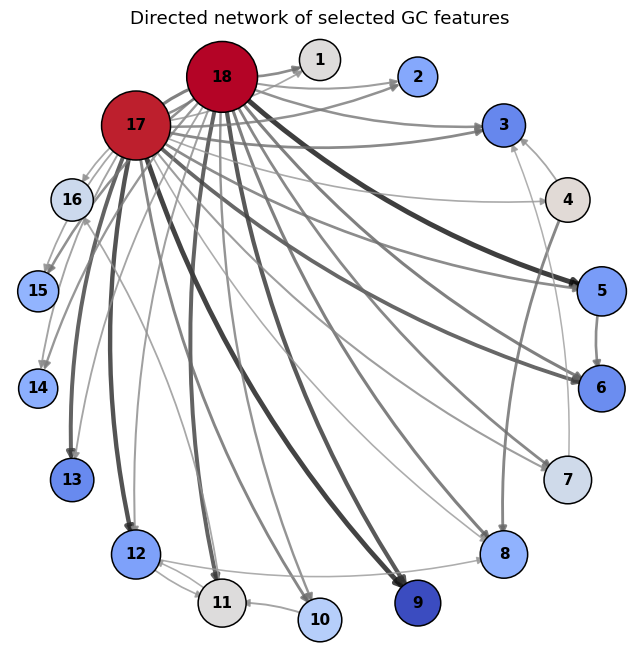

In [128]:
top20["source"]
top20["target"]

# Count connections within each patient
edges_patient = (
    top20
    .groupby(["patient", "source", "target"])
    .size()
    .reset_index(name="count")
)

# Total selected connections per patient
patient_total = (
    edges_patient
    .groupby("patient")["count"]
    .transform("sum")
)

# Normalise within patient
edges_patient["weight"] = (
    edges_patient["count"] /
    patient_total
)

# Average across patients
edges = (
    edges_patient
    .groupby(["source", "target"])["weight"]
    .mean()
    .reset_index()
    .rename(columns={
        "source": "src",
        "target": "tgt",
        "weight": "w"
    })
)

CH = sorted(set(top20["source"]) | set(top20["target"]))


import matplotlib.pyplot as plt
import networkx as nx
import math
from matplotlib.patches import FancyArrowPatch
import matplotlib.colors as mcolors


fig, ax = plt.subplots(figsize=(8,8))

draw_network(
    ax,
    edges,
    edges.groupby("src")["w"].sum(),
    edges.groupby("tgt")["w"].sum(),
    "Directed network of selected GC features",
    top_n=40
)


plt.show()

In [129]:
# Top directed GC connections
top_connections = (
    edges
    .sort_values("w", ascending=False)
    .reset_index(drop=True)
)

top_connections.head(20)

,src,tgt,w
0,18,5,0.083754
1,17,9,0.081272
2,17,12,0.072180
3,18,9,0.068517
4,17,13,0.064335
5,18,11,0.064283
6,17,6,0.062004
7,18,17,0.048404
8,18,8,0.048068
9,18,6,0.047714


In [130]:
connection_patients = (
    top20
    .groupby(["source", "target"])["patient"]
    .nunique()
    .reset_index(name="n_patients")
)

top_connections = (
    edges
    .merge(
        connection_patients,
        left_on=["src", "tgt"],
        right_on=["source", "target"]
    )
    .drop(columns=["source", "target"])
    .sort_values("w", ascending=False)
)

top_connections.head(20)

,src,tgt,w,n_patients
290,18,5,0.083754,14
277,17,9,0.081272,8
280,17,12,0.072180,8
294,18,9,0.068517,11
281,17,13,0.064335,9
296,18,11,0.064283,18
274,17,6,0.062004,13
302,18,17,0.048404,13
293,18,8,0.048068,11
291,18,6,0.047714,12


> Red = more outgoing influence (source > target)

> Blue = more incoming influence (target > source)

> Large node = the channel appears in many selected GC connections

> Arrow thickness = how often that directed connection was selected

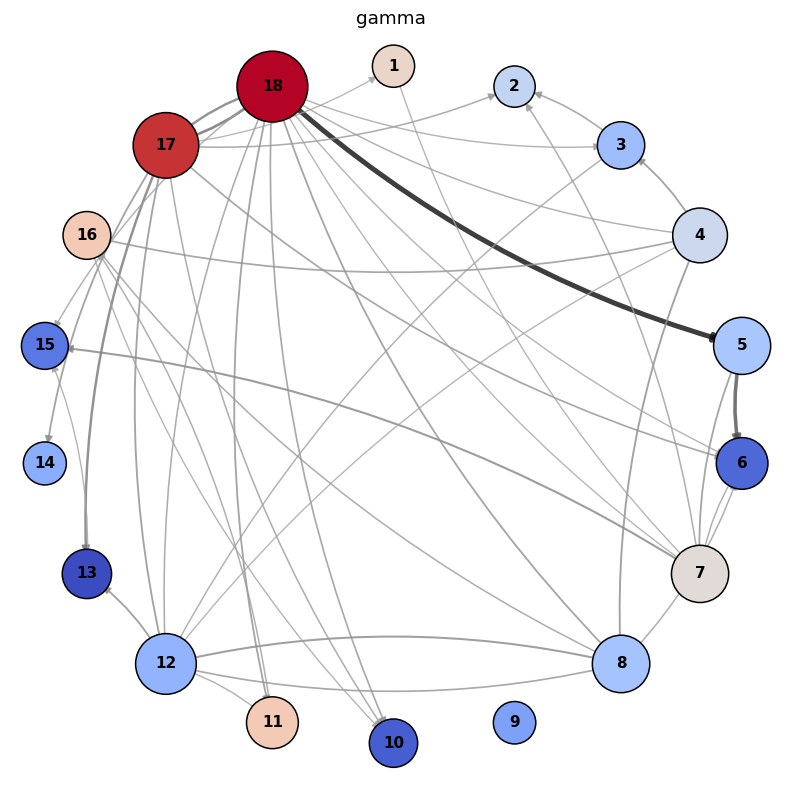

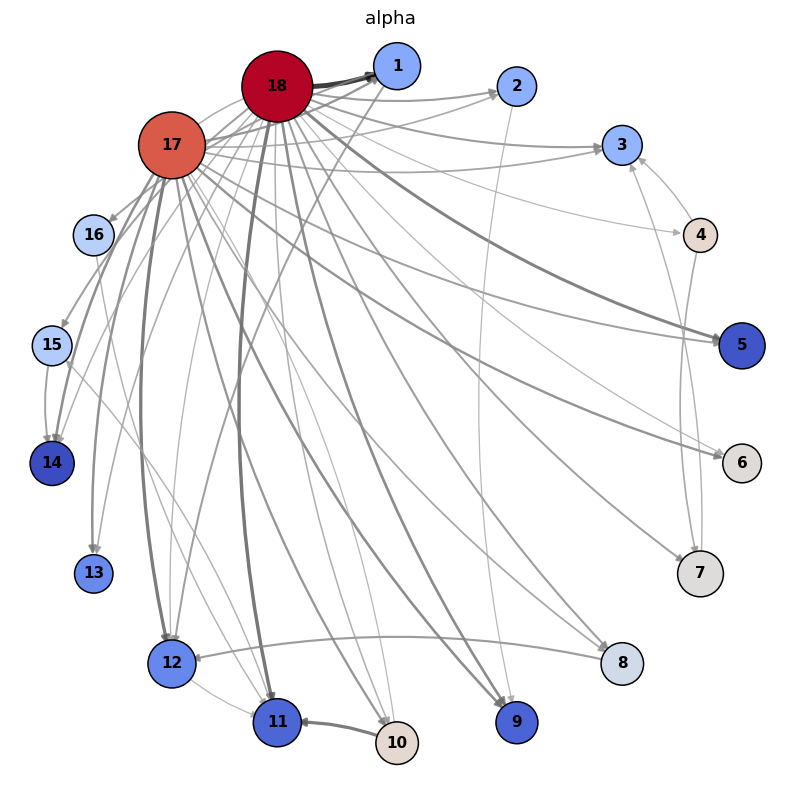

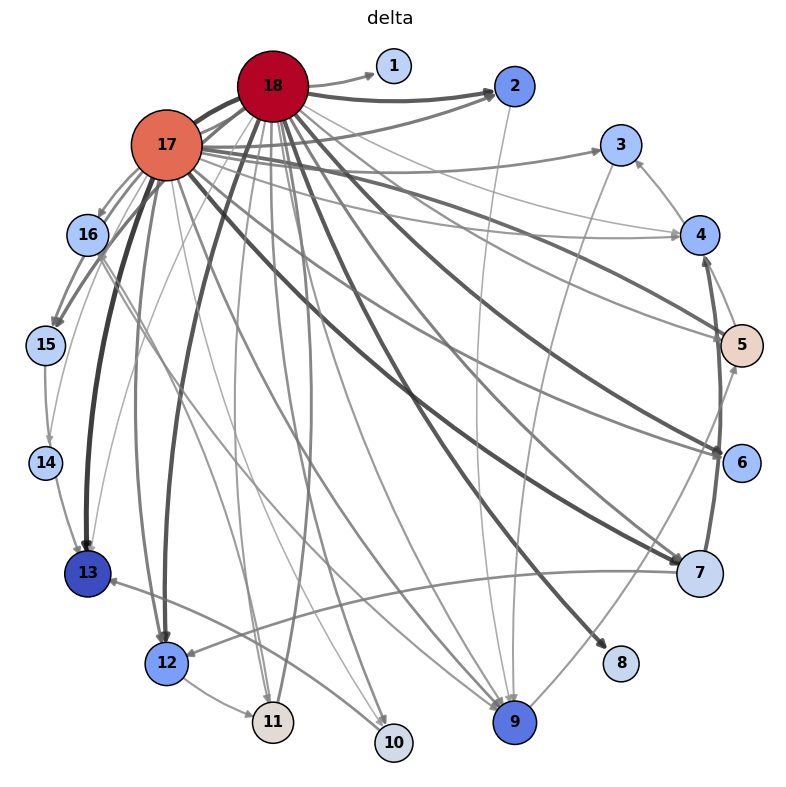

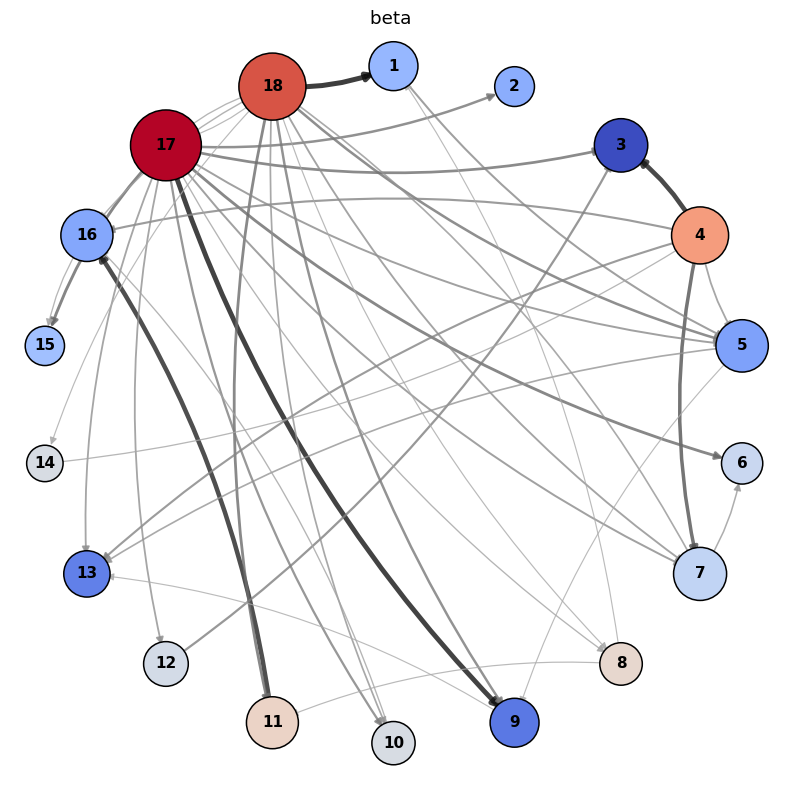

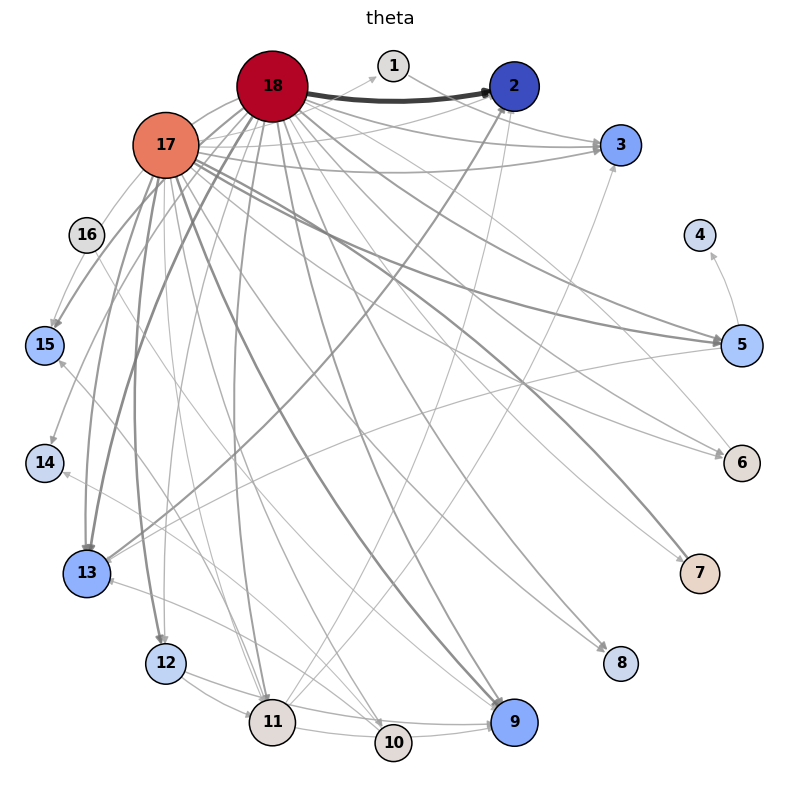

In [124]:
import matplotlib.pyplot as plt

bands = ["gamma", "alpha", "delta", "beta", "theta"]

for band in bands:

    # Select this frequency band
    band_df = top20[top20["band"] == band].copy()

    # Count connections within each patient
    edges_patient = (
        band_df
        .groupby(["patient", "source", "target"])
        .size()
        .reset_index(name="count")
    )

    # Total selected connections for this patient in this band
    patient_total = (
        edges_patient
        .groupby("patient")["count"]
        .transform("sum")
    )

    # Normalise within patient
    edges_patient["weight"] = (
        edges_patient["count"] /
        patient_total
    )

    # Average across patients
    edges_band = (
        edges_patient
        .groupby(["source", "target"])["weight"]
        .mean()
        .reset_index()
        .rename(columns={
            "source": "src",
            "target": "tgt",
            "weight": "w"
        })
    )

    # Plot
    fig, ax = plt.subplots(figsize=(8,8))

    draw_network(
        ax,
        edges_band,
        edges_band.groupby("src")["w"].sum(),
        edges_band.groupby("tgt")["w"].sum(),
        f"{band} ",
        top_n=40
    )

    plt.tight_layout()
    plt.show()

## Directionality different bands

## Directionality

In [44]:
connections = (
    top20
    .groupby(["source","target"])
    .size()
    .sort_values(ascending=False)
)

print(connections.head(20))

source  target
18      5         796
        11        634
17      6         496
18      7         453
        9         441
17      10        416
        12        366
        18        356
18      6         326
        17        316
17      9         312
18      8         308
17      2         284
        13        274
18      12        239
        15        229
17      15        220
        5         211
18      3         201
17      3         199
dtype: int64


## Per-patient band shares

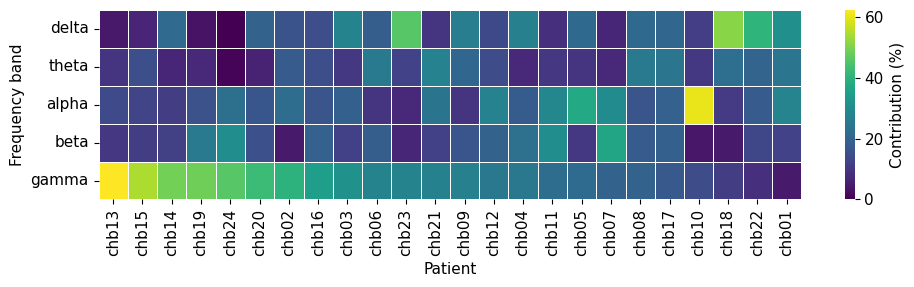

In [136]:
import seaborn as sns
import matplotlib.pyplot as plt

# Rank weighting
top20["rank_weight"] = 21 - top20["rank"]

# Sum weights within patient and band
patient_band = (
    top20
    .groupby(["patient", "band"])["rank_weight"]
    .sum()
    .reset_index()
)

# Convert to percentages within each patient
patient_band["share"] = (
    patient_band["rank_weight"] /
    patient_band.groupby("patient")["rank_weight"].transform("sum")
)

# Wide format
heat = (
    patient_band
    .pivot(index="patient", columns="band", values="share")
    .fillna(0)
)

# Order columns
heat = heat[["delta", "theta", "alpha", "beta", "gamma"]]

# Sort patients by gamma contribution
heat = heat.sort_values("gamma", ascending=False)

# Horizontal heatmap

plt.figure(figsize=(10,3))

sns.heatmap(
    heat.T * 100,          # transpose
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Contribution (%)"}
)

plt.xlabel("Patient")
plt.ylabel("Frequency band")

plt.tight_layout()
plt.show()

In [137]:
heat_table = (heat * 100).round(1)
display(heat_table)

band,delta,theta,alpha,beta,gamma
patient,,,,,
chb13,3.9,9.6,14.1,10.0,62.4
chb15,6.4,15.0,12.6,11.2,54.8
chb14,21.4,6.6,11.0,12.1,49.0
chb19,3.0,7.0,15.7,25.6,48.7
chb24,0.0,0.6,22.9,30.6,45.9
chb20,19.4,6.1,16.7,15.2,42.6
chb02,15.9,17.6,22.1,4.2,40.2
chb16,14.8,15.0,16.5,19.0,34.7
chb03,27.8,10.1,18.9,11.7,31.4


In [133]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

S = cosine_similarity(heat)

mean_cos = S[np.triu_indices_from(S,1)].mean()

print(mean_cos)

0.7818270012323746


In [134]:
dominant = heat.idxmax(axis=1)

print(dominant.value_counts())

gamma    11
delta     5
theta     3
alpha     3
beta      2
Name: count, dtype: int64


In [135]:
(heat["gamma"] > 0.20).sum()

17

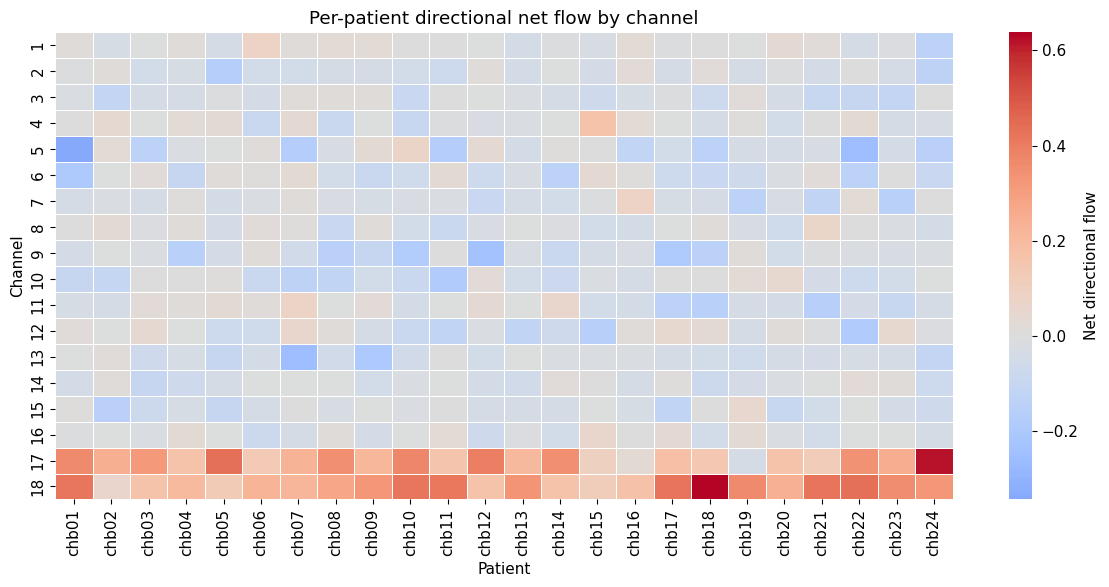

In [151]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Outgoing (source) counts

outgoing = (
    top20
    .groupby(["patient", "source"])
    .size()
    .reset_index(name="outgoing")
    .rename(columns={"source": "channel"})
)

# Incoming (target) counts

incoming = (
    top20
    .groupby(["patient", "target"])
    .size()
    .reset_index(name="incoming")
    .rename(columns={"target": "channel"})
)

# Combine incoming and outgoing

flow = (
    pd.merge(
        outgoing,
        incoming,
        on=["patient", "channel"],
        how="outer"
    )
    .fillna(0)
)

# Normalise within each patient

flow["outgoing"] = (
    flow["outgoing"] /
    flow.groupby("patient")["outgoing"].transform("sum")
)

flow["incoming"] = (
    flow["incoming"] /
    flow.groupby("patient")["incoming"].transform("sum")
)

# Net flow
# Positive = source
# Negative = sink

flow["net_flow"] = (
    flow["outgoing"] -
    flow["incoming"]
)

# Create heatmap table

heat = (
    flow
    .pivot(
        index="channel",
        columns="patient",
        values="net_flow"
    )
    .fillna(0)
)

# Order channels

heat = heat.sort_index()

# Order patients (chb01 to chb24)

patient_order = sorted(
    heat.columns,
    key=lambda x: int(x.replace("chb", ""))
)

heat = heat[patient_order]

# Plot

plt.figure(figsize=(12,6))

sns.heatmap(
    heat,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={
        "label": "Net directional flow"
    }
)

plt.xlabel("Patient")
plt.ylabel("Channel")
plt.title("Per-patient directional net flow by channel")

plt.tight_layout()
plt.show()